# RCC Subtype Classification - Mean Pooling MIL Baseline
### BME 515 Final Project
Reads .h5 feature files from features/, aggregates patch features via mean pooling,
trains SVM and MLP classifiers, reports per-class AUC and confusion matrix.
Serves as non-attention baseline for comparison against ABMIL and CLAM variants.

Notes on data setup:
- Chromophobe excluded: no training samples available in this split
- Train + Val merged as training set; Test used for evaluation
- 4 classes: Benign, Clearcell, Oncocytoma, Papillary

In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score
)

BASE_DIR = Path('/Users/zhangruikun/Desktop/BME515')
FEATURE_DIR = BASE_DIR / 'features'
META_PATH = BASE_DIR / 'MetaData_Release_1.1.csv'
OUTPUT_DIR = BASE_DIR / 'meanpool_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Chromophobe has no training samples — excluded from this experiment
EXCLUDED_CLASSES = ['Chromophobe']
TRAIN_SPLITS = ['Train', 'Val']  # merge Train + Val as training set
TEST_SPLITS  = ['Test']

print(f'Feature dir exists: {FEATURE_DIR.exists()}')
print(f'Metadata exists: {META_PATH.exists()}')
print(f'Output dir: {OUTPUT_DIR}')

Feature dir exists: True
Metadata exists: True
Output dir: /Users/zhangruikun/Desktop/BME515/meanpool_output


In [2]:
# load metadata, filter out excluded classes
meta = pd.read_csv(META_PATH)
meta = meta[~meta['Diagnosis'].isin(EXCLUDED_CLASSES)].reset_index(drop=True)

print(f'Slides after excluding {EXCLUDED_CLASSES}: {len(meta)}')
print('\nClass distribution:')
print(meta['Diagnosis'].value_counts())
print('\nSplit distribution:')
print(meta['Data Split'].value_counts())

Slides after excluding ['Chromophobe']: 540

Class distribution:
Diagnosis
Clearcell     344
Papillary     101
Oncocytoma     66
Benign         29
Name: count, dtype: int64

Split distribution:
Data Split
Train    383
Test     139
Val       18
Name: count, dtype: int64


In [3]:
# build slide-level feature matrix via mean pooling
# for each slide: load patch features [N, 2048], average across patches -> [2048]
def load_mean_features(feature_dir, meta):
    h5_files = sorted(feature_dir.glob('*.h5'))
    print(f'Found {len(h5_files)} .h5 files')

    # build lookup: DHMC_0001 -> row (strip .png from File Name)
    meta_lookup = {Path(row['File Name']).stem: row for _, row in meta.iterrows()}

    slide_ids, features, labels, splits = [], [], [], []
    skipped = 0

    for h5_path in h5_files:
        slide_name = h5_path.stem  # e.g. DHMC_0001

        if slide_name not in meta_lookup:
            skipped += 1
            continue

        row = meta_lookup[slide_name]
        label = row['Diagnosis']
        split = row['Data Split']

        with h5py.File(h5_path, 'r') as f:
            feats = f['features'][:]  # [N, 2048]

        mean_feat = feats.mean(axis=0)  # [2048] — mean pooling across all patches

        slide_ids.append(slide_name)
        features.append(mean_feat)
        labels.append(label)
        splits.append(split)

    print(f'Loaded: {len(features)} slides | Skipped (no metadata match): {skipped}')
    return (
        np.stack(features),   # [n_slides, 2048]
        np.array(labels),
        np.array(splits),
        slide_ids
    )

X, y, splits, slide_ids = load_mean_features(FEATURE_DIR, meta)

Found 484 .h5 files
Loaded: 461 slides | Skipped (no metadata match): 23


In [4]:
# split into train / test using metadata split column
# Train + Val -> training set; Test -> evaluation
train_mask = np.isin(splits, TRAIN_SPLITS)
test_mask  = np.isin(splits, TEST_SPLITS)

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

X_train, y_train = X[train_mask], y_enc[train_mask]
X_test,  y_test  = X[test_mask],  y_enc[test_mask]

print(f'Classes: {class_names}')
print(f'Train: {len(X_train)} slides | Test: {len(X_test)} slides')
print('\nTrain class counts:')
for cls, idx in zip(class_names, range(len(class_names))):
    print(f'  {cls}: {(y_train == idx).sum()}')
print('\nTest class counts:')
for cls, idx in zip(class_names, range(len(class_names))):
    print(f'  {cls}: {(y_test == idx).sum()}')

Classes: ['Benign' 'Clearcell' 'Oncocytoma' 'Papillary']
Train: 401 slides | Test: 60 slides

Train class counts:
  Benign: 19
  Clearcell: 290
  Oncocytoma: 32
  Papillary: 60

Test class counts:
  Benign: 10
  Clearcell: 20
  Oncocytoma: 10
  Papillary: 20


In [5]:
# normalize features — required for SVM, good practice for MLP
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Features normalized')

Features normalized


In [6]:
# train SVM classifier
# RBF kernel, probability=True needed for AUC computation
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')
auc_svm = roc_auc_score(y_test, y_prob_svm, multi_class='ovr', average='macro')

print(f'SVM — Accuracy: {acc_svm:.4f} | Weighted F1: {f1_svm:.4f} | Macro AUC: {auc_svm:.4f}')

SVM — Accuracy: 0.7500 | Weighted F1: 0.7332 | Macro AUC: 0.9464


In [7]:
# train MLP classifier
# two hidden layers, early stopping to avoid overfitting on small dataset
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    max_iter=300,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp, average='weighted')
auc_mlp = roc_auc_score(y_test, y_prob_mlp, multi_class='ovr', average='macro')

print(f'MLP — Accuracy: {acc_mlp:.4f} | Weighted F1: {f1_mlp:.4f} | Macro AUC: {auc_mlp:.4f}')

MLP — Accuracy: 0.8167 | Weighted F1: 0.7983 | Macro AUC: 0.9668


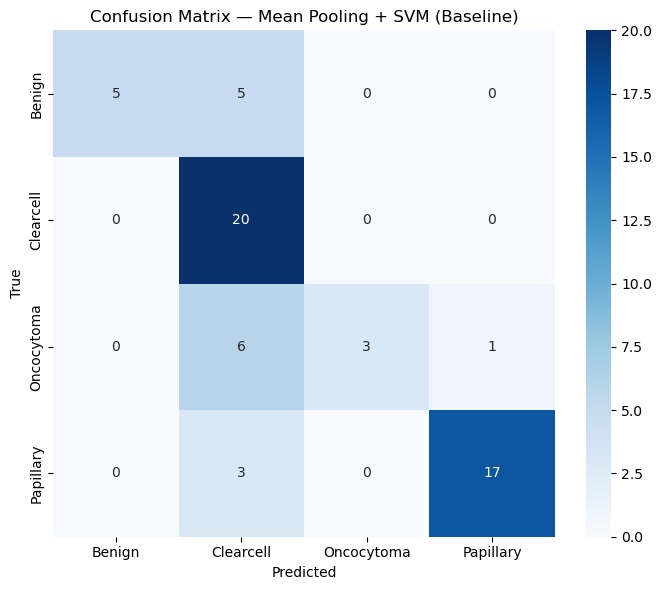

Saved confusion matrix


In [8]:
# confusion matrix for SVM (typically stronger on small datasets)
cm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Mean Pooling + SVM (Baseline)')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix_meanpool_svm.png'), dpi=150)
plt.show()
print('Saved confusion matrix')

In [9]:
# per-class classification report
print('Classification Report — SVM:')
print(classification_report(y_test, y_pred_svm, target_names=class_names))

print('Classification Report — MLP:')
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

Classification Report — SVM:
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.67        10
   Clearcell       0.59      1.00      0.74        20
  Oncocytoma       1.00      0.30      0.46        10
   Papillary       0.94      0.85      0.89        20

    accuracy                           0.75        60
   macro avg       0.88      0.66      0.69        60
weighted avg       0.84      0.75      0.73        60

Classification Report — MLP:
              precision    recall  f1-score   support

      Benign       1.00      0.40      0.57        10
   Clearcell       0.73      0.95      0.83        20
  Oncocytoma       0.86      0.60      0.71        10
   Papillary       0.87      1.00      0.93        20

    accuracy                           0.82        60
   macro avg       0.86      0.74      0.76        60
weighted avg       0.84      0.82      0.80        60



In [10]:
# summary table — SVM vs MLP side by side
summary = pd.DataFrame({
    'Model':     ['Mean Pool + SVM', 'Mean Pool + MLP'],
    'Accuracy':  [round(acc_svm, 4), round(acc_mlp, 4)],
    'W. F1':     [round(f1_svm,  4), round(f1_mlp,  4)],
    'Macro AUC': [round(auc_svm, 4), round(auc_mlp, 4)]
})
print('\n--- Baseline Results ---')
print(summary.to_string(index=False))
summary.to_csv(str(OUTPUT_DIR / 'baseline_results.csv'), index=False)
print(f'\nSaved to {OUTPUT_DIR / "baseline_results.csv"}')


--- Baseline Results ---
          Model  Accuracy  W. F1  Macro AUC
Mean Pool + SVM    0.7500 0.7332     0.9464
Mean Pool + MLP    0.8167 0.7983     0.9668

Saved to /Users/zhangruikun/Desktop/BME515/meanpool_output/baseline_results.csv
